In [ ]:
import numpy as np
import pandas as pd
import random
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [ ]:
df1 = pd.read_csv(r'C:/Users/Mohan/Downloads/movies.csv')
df1.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [ ]:
df2 = pd.read_csv(r'C:/Users/Mohan/Downloads/credits.csv')
df2.rename(columns={'movie_id': 'id'}, inplace=True)
df2.head()

,id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      4803 non-null   int64 
 1   title   4803 non-null   object
 2   cast    4803 non-null   object
 3   crew    4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


,id
count,4803.000000
mean,57165.484281
std,88694.614033
min,5.000000
25%,9014.500000
50%,14629.000000
75%,58610.500000
max,459488.000000


In [ ]:
df1.dropna(axis = 0, inplace=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1493 entries, 0 to 4801
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                1493 non-null   int64  
 1   genres                1493 non-null   object 
 2   homepage              1493 non-null   object 
 3   id                    1493 non-null   int64  
 4   keywords              1493 non-null   object 
 5   original_language     1493 non-null   object 
 6   original_title        1493 non-null   object 
 7   overview              1493 non-null   object 
 8   popularity            1493 non-null   float64
 9   production_companies  1493 non-null   object 
 10  production_countries  1493 non-null   object 
 11  release_date          1493 non-null   object 
 12  revenue               1493 non-null   int64  
 13  runtime               1493 non-null   float64
 14  spoken_languages      1493 non-null   object 
 15  status                1493

In [ ]:
merged = df1.merge(df2, on='id')
merged.drop_duplicates(inplace=True)
merged.drop(['homepage', 'production_countries', 'release_date', 'status'], axis=1, inplace=True)
merged.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,revenue,runtime,spoken_languages,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
# JSON parsers
def convert_json(text):
    try:
        return [i['name'] for i in ast.literal_eval(text)]
    except:
        return []

def get_director(text):
    try:
        return [i['name'] for i in ast.literal_eval(text) if i.get('job') == 'Director']
    except:
        return []

In [ ]:
merged['genres'] = merged['genres'].apply(convert_json)
merged['cast'] = merged['cast'].apply(lambda x: convert_json(x)[:3])
merged['keywords'] = merged['keywords'].apply(convert_json)
merged['crew'] = merged['crew'].apply(get_director)
merged['overview'] = merged.get('overview', '').fillna('')
# Combine tags
merged['tags'] = merged['genres'] + merged['cast'] + merged['crew'] + merged['keywords'] + merged['overview'].apply(lambda x: x.split())
merged['tags'] = merged['tags'].apply(lambda x: ' '.join(x).lower())
merged.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,revenue,runtime,spoken_languages,tagline,title_x,vote_average,vote_count,title_y,cast,crew,tags
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron],action adventure fantasy science fiction sam w...
1,300000000,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski],adventure fantasy action johnny depp orlando b...
2,245000000,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes],action adventure crime daniel craig christoph ...
3,250000000,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan],action crime drama thriller christian bale mic...
4,260000000,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton],action adventure science fiction taylor kitsch...


In [ ]:
# Normalize features
scaler = StandardScaler()
numerical_features = ['budget', 'popularity', 'vote_count', 'revenue']
merged[numerical_features] = scaler.fit_transform(merged[numerical_features])
merged.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,revenue,runtime,spoken_languages,tagline,title_x,vote_average,vote_count,title_y,cast,crew,tags
0,3.560456,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",2.379851,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",10.934636,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,Avatar,7.2,5.846690,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron],action adventure fantasy science fiction sam w...
1,4.734205,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",2.144229,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",3.347273,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,1.772708,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski],adventure fantasy action johnny depp orlando b...
2,3.709504,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,A cryptic message from Bond’s past sends him o...,1.486314,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",3.013683,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,Spectre,6.3,1.753734,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes],action adventure crime daniel craig christoph ...
3,3.802658,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,1.588742,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",3.861991,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,The Dark Knight Rises,7.6,4.343224,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan],action crime drama thriller christian bale mic...
4,3.988968,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...",en,John Carter,"John Carter is a war-weary, former military ca...",0.169692,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",0.536278,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",John Carter,6.1,0.446711,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton],action adventure science fiction taylor kitsch...


In [ ]:
#This line is written because the 2 datasets contains column called title so when merged its giving as title_x and title_y so our program cannot identify the title column
title_col = 'title' if 'title' in merged.columns else 'original_title'
merged.rename(columns={title_col: 'title'}, inplace=True)

In [ ]:
# Final DF
final = merged[['id', 'title', 'tags', 'vote_average'] + numerical_features].copy()
final.head()

,id,title,tags,vote_average,budget,popularity,vote_count,revenue
0,19995,Avatar,action adventure fantasy science fiction sam w...,7.2,3.560456,2.379851,5.846690,10.934636
1,285,Pirates of the Caribbean: At World's End,adventure fantasy action johnny depp orlando b...,6.9,4.734205,2.144229,1.772708,3.347273
2,206647,Spectre,action adventure crime daniel craig christoph ...,6.3,3.709504,1.486314,1.753734,3.013683
3,49026,The Dark Knight Rises,action crime drama thriller christian bale mic...,7.6,3.802658,1.588742,4.343224,3.861991
4,49529,John Carter,action adventure science fiction taylor kitsch...,6.1,3.988968,0.169692,0.446711,0.536278


In [ ]:
# TF-IDF
cv = TfidfVectorizer(max_features=3000, stop_words='english')
vector = cv.fit_transform(final['tags'])
similarity = cosine_similarity(vector)
print(vector)

  (0, 482)	0.15196045172091605
  (0, 2104)	0.16204140461525326
  (0, 1929)	0.15488885470913888
  (0, 1018)	0.1333826924114482
  (0, 2713)	0.14480790181480163
  (0, 1773)	0.09389675142666556
  (0, 2801)	0.146971238622737
  (0, 1795)	0.13765535190868725
  (0, 426)	0.11891455798861245
  (0, 18)	0.09957873114465346
  (0, 2488)	0.12973773582228537
  (0, 1762)	0.12286933402642197
  (0, 2199)	0.15820880419935238
  (0, 2054)	0.11139904267231716
  (0, 129)	0.12464599602612718
  (0, 46)	0.13089434850456352
  (0, 1625)	0.07523471173470488
  (0, 233)	0.1039777043210028
  (0, 2477)	0.13089434850456352
  (0, 1671)	0.2667653848228964
  (0, 2020)	0.12121120712145443
  (0, 82)	0.31437884246733894
  (0, 2294)	0.0691128872088714
  (0, 1065)	0.14934090598435346
  (0, 2752)	0.11891455798861245
  :	:
  (1492, 2958)	0.20636961573877136
  (1492, 177)	0.1982191837416336
  (1492, 2465)	0.20203903057295355
  (1492, 1437)	0.1692315849548205
  (1492, 2562)	0.15608185927669954
  (1492, 2977)	0.20636961573877136
  (

In [ ]:
sample_size = 10000  # Number of movie pairs to sample for training
X = []
y = []
for _ in range(sample_size):
    # Randomly select two distinct movie indices
    i, j = random.sample(range(100), 2)
    # Convert sparse vectors to dense and flatten
    vector_i = vector[i].toarray().flatten().tolist()
    vector_j = vector[j].toarray().flatten().tolist()
    # Concatenate and add to training data
    X.append(vector_i + vector_j)
    # Label based on similarity threshold
    y.append(1 if similarity[i][j] > 0.5 else 0)
print(vector_i)
print(vector_j)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06109827619566411, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0684651149572273, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12951797425891481, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train Models
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
log_model = LogisticRegression(max_iter=1400)
log_model.fit(X_train, y_train)


LogisticRegression(max_iter=1400)

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
print("KNN Accuracy:", accuracy_score(y_test, knn_model.predict(X_test)))
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_model.predict(X_test)))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_model.predict(X_test)))

KNN Accuracy: 0.999
Logistic Regression Accuracy: 0.9985
Random Forest Accuracy: 0.9995


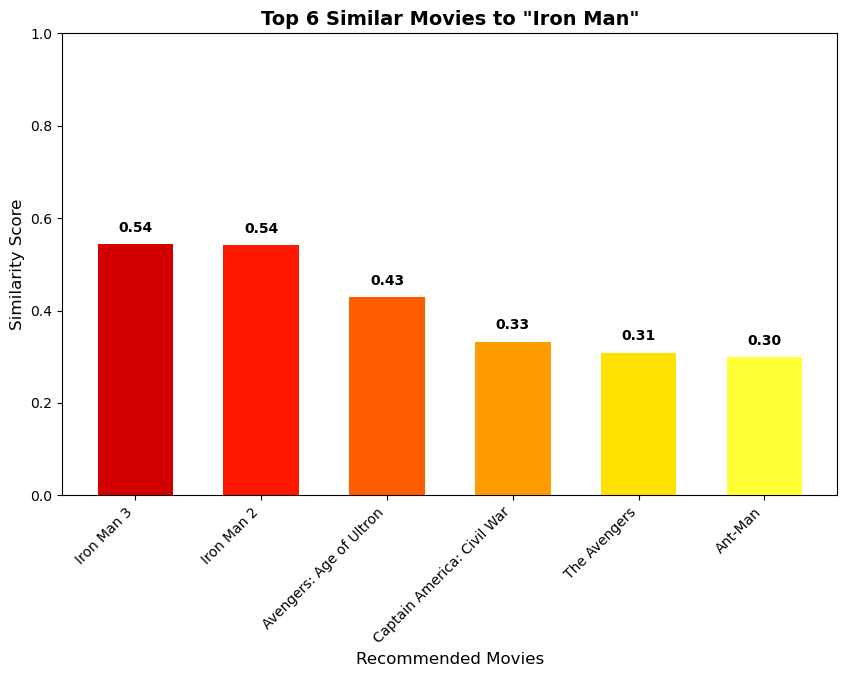

['Iron Man 3', 'Iron Man 2', 'Avengers: Age of Ultron', 'Captain America: Civil War', 'The Avengers', 'Ant-Man']


In [ ]:
def recommend(movie_title, top_n=5, visualize=True):
    movie_title = movie_title.lower()
    if movie_title not in final['title'].str.lower().values:
        return f"Movie '{movie_title}' not found in dataset."
    idx = final[final['title'].str.lower() == movie_title].index[0]
    distances = similarity[idx]
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:top_n+1]
    recommended_titles = [final.iloc[i[0]]['title'] for i in movie_list]
    similarity_scores = [i[1] for i in movie_list]
    if visualize:
        plt.figure(figsize=(10, 6))
        colors = plt.cm.hot(np.linspace(0.3, 0.8, top_n))
        bars = plt.bar(recommended_titles, similarity_scores, color=colors, width=0.6)
        plt.ylabel("Similarity Score", fontsize=12)
        plt.xlabel("Recommended Movies", fontsize=12)
        plt.title(f"Top {top_n} Similar Movies to \"{final.iloc[idx]['title']}\"", fontsize=14, fontweight='bold')
        plt.ylim(0, 1)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        # Add labels on top of each bar
        for bar, score in zip(bars, similarity_scores):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                     f'{score:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        plt.show()
    return recommended_titles
print(recommend("Iron Man", top_n=6))

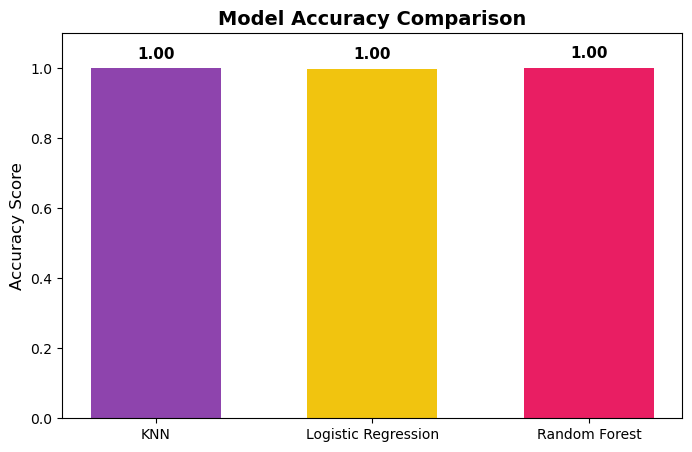

In [ ]:
# Accuracy scores
knn_acc = accuracy_score(y_test, knn_model.predict(X_test))
log_acc = accuracy_score(y_test, log_model.predict(X_test))
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
# Bar chart comparison
models = ['KNN', 'Logistic Regression', 'Random Forest']
accuracies = [knn_acc, log_acc, rf_acc]
plt.figure(figsize=(8, 5))
colors = plt.cm.hot(np.linspace(0.3, 0.8))
bars = plt.bar(models, accuracies, color= ['#8e44ad', '#f1c40f', '#e91e63']  , width=0.6)
# Add value labels clearly above the bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x()+ bar.get_width()/2, height + 0.02,  # moved higher
             f'{acc:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
plt.ylim(0, max(accuracies) + 0.1)  # Extend y-axis to prevent overlap
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy Score", fontsize=12)
plt.show()